# model training

## import required packages

In [1]:
# Basic Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
# Modelling
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge,Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings



## read data

In [2]:
df = pd.read_csv('data/preprocessed_student_data.csv')

df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [3]:
X = df.drop(['math_score'],axis=1)
Y = df.loc[:,'math_score']

In [4]:
X.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75


In [5]:
Y.head()

0    72
1    69
2    90
3    47
4    76
Name: math_score, dtype: int64

## train test split data

In [6]:
from sklearn.model_selection import train_test_split

train_x, test_x, train_y, test_y = train_test_split(X,Y,test_size=0.2,random_state=42)

In [7]:
print(type(train_x))
print(type(train_y))
print(type(test_x))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>
<class 'pandas.core.frame.DataFrame'>


In [8]:
print(f"Train X shape: {train_x.shape}")
print(f"Train Y shape: {train_y.shape}")
print(f"Test X shape: {test_x.shape}")
print(f"Test Y shape: {test_y.shape}")

Train X shape: (800, 7)
Train Y shape: (800,)
Test X shape: (200, 7)
Test Y shape: (200,)


In [9]:
numerical_features = train_x.select_dtypes(exclude=['object']).columns.tolist()
categorical_features = train_x.select_dtypes(include=['object']).columns.tolist()

In [10]:
numerical_features

['reading_score', 'writing_score']

In [11]:
categorical_features

['gender',
 'race_ethnicity',
 'parental_level_of_education',
 'lunch',
 'test_preparation_course']

## scaling and encoding features

In [12]:
from sklearn.preprocessing import StandardScaler, Normalizer,RobustScaler , OneHotEncoder
from sklearn.compose import ColumnTransformer

standard_scaler = StandardScaler()
normalizer = Normalizer()
robust_scaler = RobustScaler()
oh_encoder = OneHotEncoder(sparse=False,handle_unknown='ignore')

preprocessor = ColumnTransformer([
    ('standard_scaler',standard_scaler,numerical_features),
    ('onehot_encoder',oh_encoder,categorical_features)
])

In [13]:
x_train_transformed = preprocessor.fit_transform(train_x)
x_test_transformed = preprocessor.transform(test_x)

/home/samir/DataScience_Projects/mlproject/venv/lib/python3.8/site-packages/sklearn/preprocessing/_encoders.py:975: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


In [14]:
type(x_train_transformed), type(x_test_transformed)

(numpy.ndarray, numpy.ndarray)

In [15]:
x_train_transformed.shape, x_test_transformed.shape

((800, 19), (200, 19))

In [16]:
x_train_transformed[:5]

array([[ 0.03079054,  0.43405338,  1.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  1.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  1.        ,  0.        ,  0.        ,
         0.        ,  1.        ,  0.        ,  1.        ],
       [ 0.9302895 ,  0.96470125,  1.        ,  0.        ,  0.        ,
         0.        ,  1.        ,  0.        ,  0.        ,  0.        ,
         1.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         1.        ,  0.        ,  1.        ,  0.        ],
       [ 1.34544287,  1.1636942 ,  1.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  1.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  1.        ,  0.        ,
         1.        ,  0.        ,  0.        ,  1.        ],
       [-0.17678614, -0.16292548,  0.        ,  1.        ,  0.        ,
         0.        ,  1.        ,  0.        ,  0.        ,  0.        ,
         0.   

### evaluate model function

In [17]:
def evaluate_mode(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mse)
    r2 = r2_score(true, predicted)
    
    return mae, mse, rmse, r2

## train model

In [18]:
models = {
    
    "KNN": KNeighborsRegressor(),
    "DecisionTree": DecisionTreeRegressor(),
    "RandomForest": RandomForestRegressor(),
    "AdaBoost": AdaBoostRegressor(),
    "SVR": SVR(),
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "CatBoost": CatBoostRegressor(verbose=0),
    "XGBoost": XGBRegressor()
}

r2_list = []

for model_name in models.keys():

    model = models[model_name]
    # training the model
    model.fit(x_train_transformed, train_y)

    y_train_pred = model.predict(x_train_transformed)
    y_test_pred = model.predict(x_test_transformed)

    # evaluating the model
    train_mae, train_mse, train_rmse, train_r2 = evaluate_mode(train_y, y_train_pred)
    test_mae, test_mse, test_rmse, test_r2 = evaluate_mode(test_y, y_test_pred)

    print(f"Model: {model_name}")
    print(f"Train MAE: {train_mae:.4f} | Train MSE: {train_mse:.4f} | Train RMSE: {train_rmse:.4f} | Train R2: {train_r2:.4f}")
    print(f"Test MAE: {test_mae:.4f} | Test MSE: {test_mse:.4f} | Test RMSE: {test_rmse:.4f} | Test R2: {test_r2:.4f}")
    print("-" * 50) 

    r2_list.append(test_r2)

Model: KNN
Train MAE: 4.5083 | Train MSE: 32.4802 | Train RMSE: 5.6991 | Train R2: 0.8559
Test MAE: 5.5990 | Test MSE: 52.5714 | Test RMSE: 7.2506 | Test R2: 0.7840
--------------------------------------------------
Model: DecisionTree
Train MAE: 0.0187 | Train MSE: 0.0781 | Train RMSE: 0.2795 | Train R2: 0.9997
Test MAE: 6.3700 | Test MSE: 63.0600 | Test RMSE: 7.9410 | Test R2: 0.7409
--------------------------------------------------
Model: RandomForest
Train MAE: 1.7883 | Train MSE: 5.1108 | Train RMSE: 2.2607 | Train R2: 0.9773
Test MAE: 4.6321 | Test MSE: 35.6772 | Test RMSE: 5.9730 | Test R2: 0.8534
--------------------------------------------------
Model: AdaBoost
Train MAE: 4.7429 | Train MSE: 33.9790 | Train RMSE: 5.8292 | Train R2: 0.8493
Test MAE: 4.7861 | Test MSE: 37.5511 | Test RMSE: 6.1279 | Test R2: 0.8457
--------------------------------------------------
Model: SVR
Train MAE: 4.8663 | Train MSE: 43.1920 | Train RMSE: 6.5721 | Train R2: 0.8084
Test MAE: 5.3951 | Test M

In [19]:
pd.DataFrame({
    "Model": list(models.keys()),
    "R2 Score": r2_list
}).sort_values(by="R2 Score", ascending=False).reset_index(drop=True)

,Model,R2 Score
0,Ridge,0.880592
1,LinearRegression,0.880433
2,RandomForest,0.853384
3,CatBoost,0.851831
4,AdaBoost,0.845684
5,Lasso,0.825447
6,XGBoost,0.821220
7,KNN,0.783958
8,DecisionTree,0.740855
9,SVR,0.729105


## Linear Regression

In [20]:
lin_model = LinearRegression(fit_intercept=True)
lin_model.fit(x_train_transformed, train_y)
y_pred = lin_model.predict(x_test_transformed)

score = r2_score(test_y, y_pred)*100
print(" Accuracy of the model is %.2f" %score)

 Accuracy of the model is 88.04


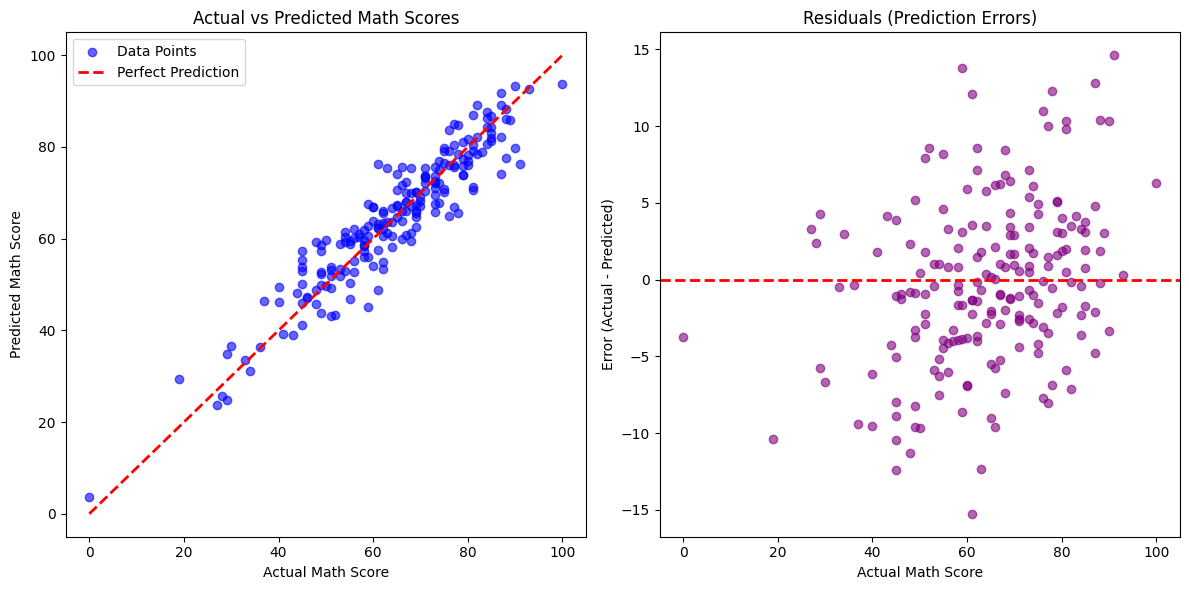

In [21]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# الرسم الأول: القيم الفعلية مقابل التوقعات
ax[0].scatter(test_y, y_pred, color='blue', alpha=0.6, label='Data Points')
# رسم خط قطري يمثل التوقع المثالي (حيث القيمة الفعلية = التوقع)
ax[0].plot([test_y.min(), test_y.max()], [test_y.min(), test_y.max()], 'r--', lw=2, label='Perfect Prediction')
ax[0].set_title('Actual vs Predicted Math Scores')
ax[0].set_xlabel('Actual Math Score')
ax[0].set_ylabel('Predicted Math Score')
ax[0].legend()

# الرسم الثاني: تحليل الأخطاء (Residuals)
# الخطأ = القيمة الفعلية - القيمة المتوقعة
residuals = test_y - y_pred 
ax[1].scatter(test_y, residuals, color='purple', alpha=0.6)
# رسم خط عند الصفر (لا يوجد خطأ)
ax[1].axhline(y=0, color='r', linestyle='--', lw=2)
ax[1].set_title('Residuals (Prediction Errors)')
ax[1].set_xlabel('Actual Math Score')
ax[1].set_ylabel('Error (Actual - Predicted)')

# تنسيق المسافات بين الرسومات وعرضها
plt.tight_layout()
plt.show()

In [22]:
pd.DataFrame({
    "Actual": test_y,
    "Predicted": y_pred,
    "Error": test_y - y_pred
}).reset_index(drop=True).tail(10)

,Actual,Predicted,Error
190,49,52.725000,-3.725000
191,68,61.192956,6.807044
192,77,66.975391,10.024609
193,78,65.700592,12.299408
194,60,54.116204,5.883796
195,52,43.409149,8.590851
196,62,62.152214,-0.152214
197,74,67.888395,6.111605
198,65,67.022287,-2.022287
199,61,62.345132,-1.345132


In [23]:
test_y.shape, y_pred.shape

((200,), (200,))

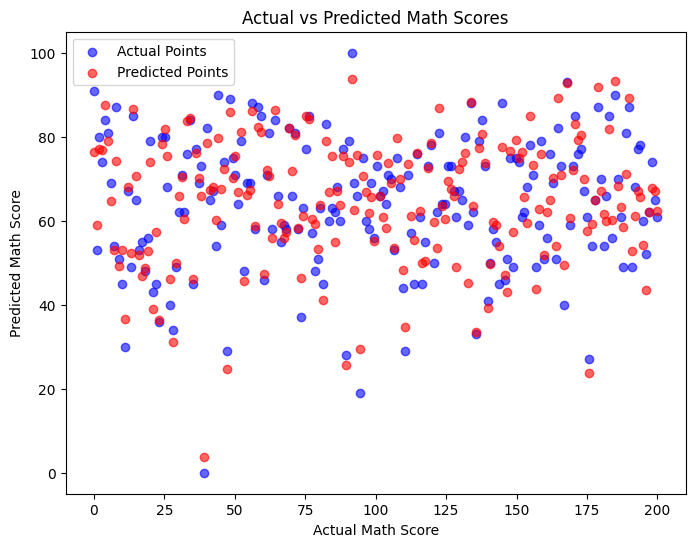

In [24]:
x = np.linspace(0, 200, 200)

fig, ax = plt.subplots(figsize=(8, 6))

plt.scatter(x,test_y, color='blue', alpha=0.6, label='Actual Points')
plt.scatter(x, y_pred, color='red', alpha=0.6, label='Predicted Points')

plt.title('Actual vs Predicted Math Scores')
plt.xlabel('Actual Math Score')
plt.ylabel('Predicted Math Score')
plt.legend()